In [1]:
import json
import pandas as pd
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# CONFIG
parent_dir = Path("model_outputs")
# data_folder = "llmchess-testdifficulty-qwen25-7b-1k_fixedids"
data_folder = "llmchess-testdifficulty-qwen25-7b-sft-dm6-1000_fixedids"
INCLUDE_ERRORS = False 
light_col, dark_col = "#d9d9d9", "#555555"

# Start by aggregating into single dataframe

In [3]:
master = {}                     # board_id → aggregated metrics

for jf in (parent_dir / data_folder).glob("*.json"):
    task = jf.stem.split('_')[0]               # bestmove / worstmove / …
    with open(jf, encoding="utf-8") as fh:
        records = json.load(fh)

    for board_id, rec in records.items():
        raw_scores = [s for s, _ in rec["score_answers"]]

        # Count errors (non‑numeric scores) first
        err_count = sum(1 for v in raw_scores if not isinstance(v, (int, float)))

        # Handle errors per flag
        if INCLUDE_ERRORS:
            scores = [v if isinstance(v, (int, float)) else 0 for v in raw_scores]
        else:
            scores = [v for v in raw_scores if isinstance(v, (int, float))]

        # Skip rows with no valid numeric scores when we're ignoring errors
        if not scores:
            continue

        avg_score = sum(scores) / len(scores)
        nz_count  = sum(1 for v in scores if v > 0)

        if task in ("bestmove", "worstmove"):
            success = any(v == 1 for v in scores)
        elif task == "predictmove":
            success = any(v > 0.8 for v in scores)
        elif task == "legalmoves":
            success = any(v > 0.8 for v in scores)
        else:
            success = False

        master.setdefault(board_id, {})
        master[board_id][f"{task}_avg_score"]   = avg_score
        master[board_id][f"{task}_success"]     = int(success)
        master[board_id][f"{task}_nz_count"]    = nz_count
        # master[board_id][f"{task}_error_count"] = err_count

# ── Lastly loop through a single file and scrape board data ──────────────────
pred_file = next((parent_dir / data_folder).glob("*predictmove*.json"), None)
if pred_file is None:
    raise FileNotFoundError("No predictmove JSON found in folder")

with pred_file.open(encoding="utf-8") as fh:
    pred_records = json.load(fh)

for board_id, rec in pred_records.items():
    fen_parts   = rec["info"]["board"].split(" ")
    color       = fen_parts[1]              # 'w' or 'b'
    move_count  = int(fen_parts[-1])        # full‑move number
    max_winprob = max(rec["info"]["answer"].values())

    master.setdefault(board_id, {})
    master[board_id]["color"]        = color
    master[board_id]["move_count"]   = move_count
    master[board_id]["max_win_prob"] = max_winprob

# ── Final aggregated DataFrame ───────────────────────────────────────────────
df = pd.DataFrame.from_dict(master, orient="index")
df.index.name = "board_id"

df.head(n=8)

,bestmove_avg_score,bestmove_success,bestmove_nz_count,legalmoves_avg_score,legalmoves_success,legalmoves_nz_count,predictmove_avg_score,predictmove_success,predictmove_nz_count,worstmove_avg_score,worstmove_success,worstmove_nz_count,color,move_count,max_win_prob
board_id,,,,,,,,,,,,,,,
L0AXAI,0.666667,1,4,0.916667,1,6,0.271930,0.0,3.0,0.166667,1,1,w,18,0.637229
YL8BEJ,0.833333,1,5,0.916667,1,6,0.945000,1.0,5.0,0.666667,1,4,b,4,0.402759
4ZC1QC,0.400000,1,2,0.198082,0,6,0.326531,0.0,1.0,0.666667,1,4,b,9,0.616564
T0P5UL,0.600000,1,3,0.833333,1,5,NaN,NaN,NaN,0.166667,1,1,b,9,0.446812
VHA653,0.000000,0,0,0.279762,0,3,0.663265,1.0,4.0,0.000000,0,0,w,9,0.813487
I93WWQ,0.333333,1,2,0.944444,1,6,0.636364,1.0,2.0,0.500000,1,3,w,13,0.591026
KQTEQZ,0.166667,1,1,0.152503,0,6,0.500000,1.0,4.0,0.166667,1,1,b,36,0.969344
KB4W96,0.000000,0,0,0.105556,0,5,NaN,NaN,NaN,0.166667,1,1,b,25,0.382566


# Now analyze / visualize

In [4]:
df.describe()

,bestmove_avg_score,bestmove_success,bestmove_nz_count,legalmoves_avg_score,legalmoves_success,legalmoves_nz_count,predictmove_avg_score,predictmove_success,predictmove_nz_count,worstmove_avg_score,worstmove_success,worstmove_nz_count,move_count,max_win_prob
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,921.000000,921.000000,921.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,0.275233,0.607000,1.640000,0.506470,0.440000,5.15200,0.562764,0.492942,2.816504,0.324767,0.64000,1.923000,18.565000,0.632472
std,0.307842,0.488661,1.838962,0.316478,0.496635,1.19261,0.247812,0.500222,1.450633,0.340402,0.48024,2.024146,11.784254,0.178129
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,2.000000,0.245449
25%,0.000000,0.000000,0.000000,0.229792,0.000000,5.00000,0.384615,0.000000,2.000000,0.000000,0.00000,0.000000,9.000000,0.500000
50%,0.166667,1.000000,1.000000,0.391038,0.000000,6.00000,0.564103,0.000000,3.000000,0.166667,1.00000,1.000000,16.000000,0.579856
75%,0.500000,1.000000,3.000000,0.833333,1.000000,6.00000,0.777778,1.000000,4.000000,0.600000,1.00000,3.000000,25.000000,0.787188
max,1.000000,1.000000,6.000000,1.000000,1.000000,6.00000,0.980392,1.000000,6.000000,1.000000,1.00000,6.000000,81.000000,1.000000


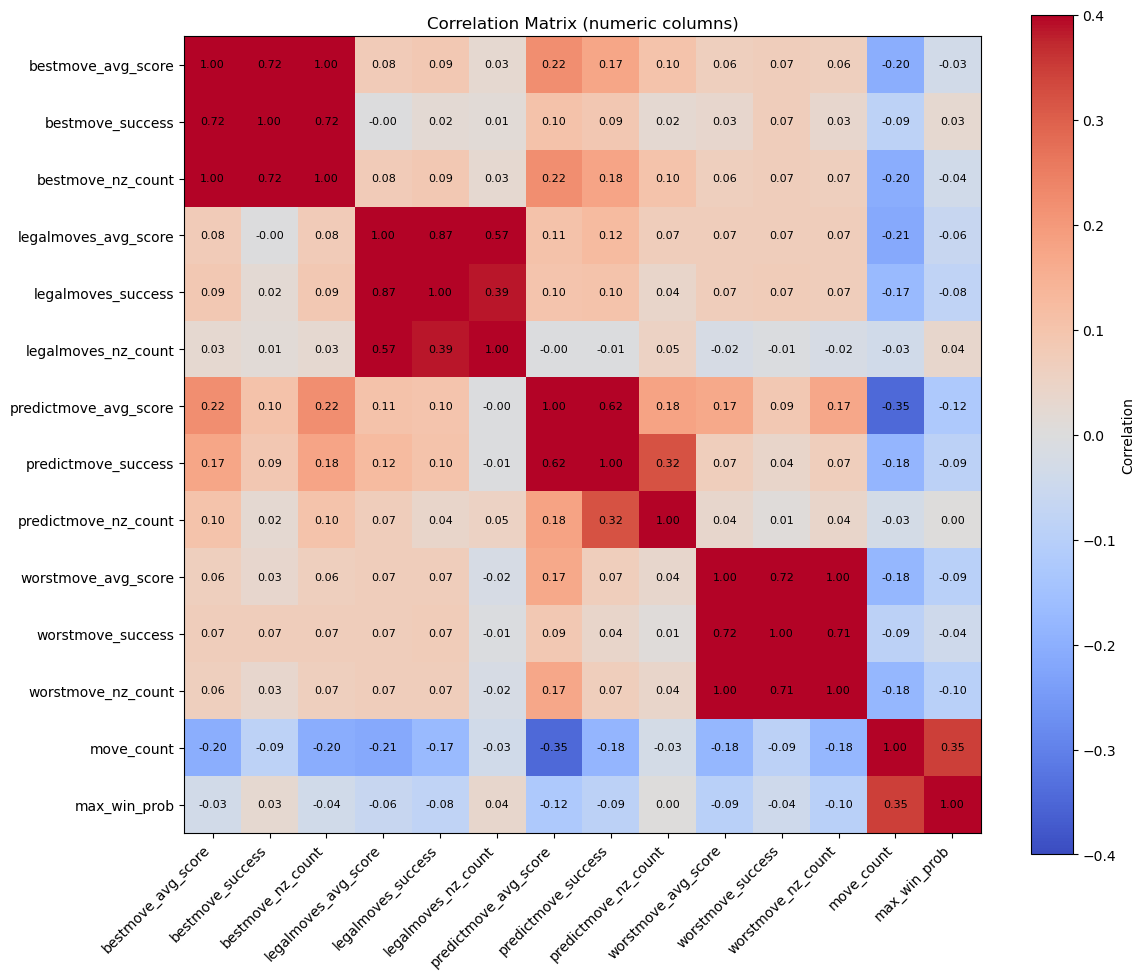

In [5]:
# Output the Correlation Matrix
num_df       = df.select_dtypes(include=[np.number])      # keeps only numeric
corr_matrix  = num_df.corr()

cols = corr_matrix.columns
fig, ax = plt.subplots(figsize=(12, 10))
cax = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-0.4, vmax=0.4)
fig.colorbar(cax, ax=ax, label="Correlation")

ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

plt.title("Correlation Matrix (numeric columns)")
plt.tight_layout()
plt.show()

# Choose X / Y Axes for Bar Charts   
---

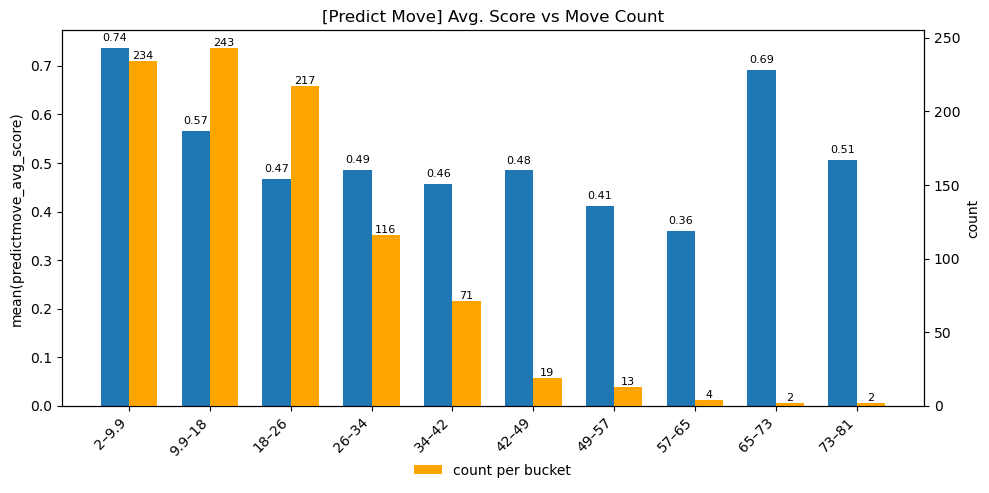

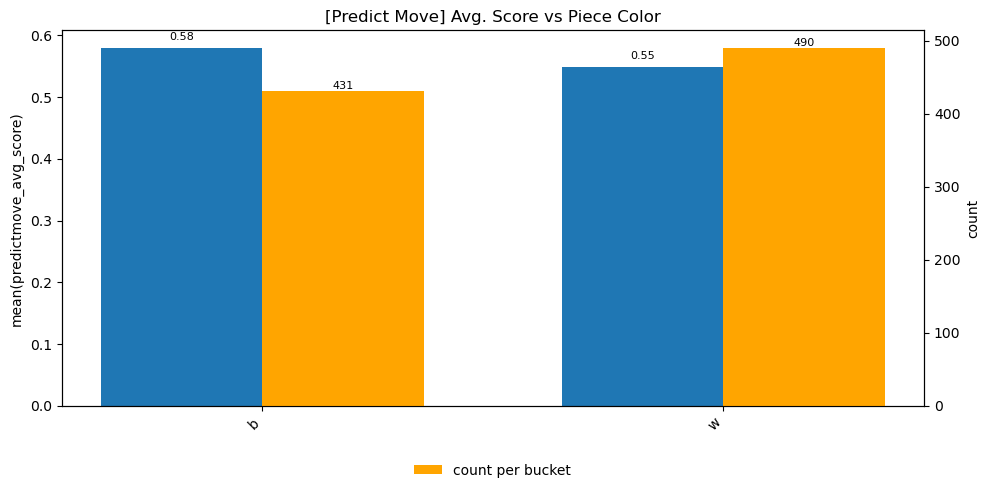

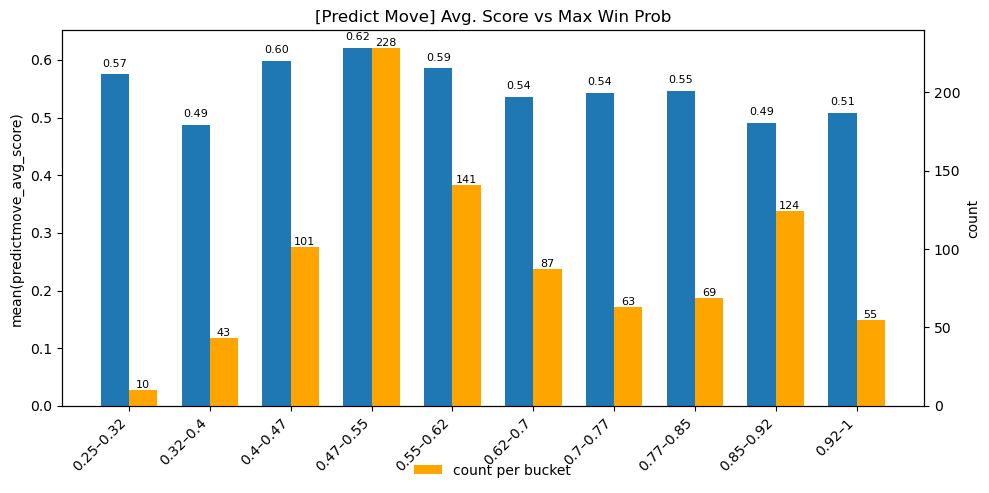

In [6]:
def bar_by(df, x_col, y_col, n_bins=10, title=None):
    """
    Dual‑axis bar plot:
      • left  y‑axis: mean(y_col) per bucket (blue)
      • right y‑axis: count per bucket (orange) — only this appears in the legend.

    Buckets: unique values if ≤10 else n_bins equal‑width numeric buckets.
    """
    import numpy as np, matplotlib.pyplot as plt, pandas as pd

    x, y = df[x_col], df[y_col]

    # ── Bucket assignment ────────────────────────────────────────────────
    if pd.api.types.is_numeric_dtype(x):
        if x.nunique() <= 10:
            labels = sorted(x.unique())
            grp_idx = x
        else:
            bins   = np.linspace(x.min(), x.max(), n_bins + 1)
            labels = [f"{bins[i]:.2g}–{bins[i+1]:.2g}" for i in range(n_bins)]
            grp_idx = pd.cut(x, bins=bins, labels=labels, include_lowest=True)
    else:
        labels  = sorted(x.astype(str).unique())
        if len(labels) > 10:
            raise ValueError(f"{x_col} has >10 categories; bucket manually")
        grp_idx = x.astype(str)

    # ── Aggregation ──────────────────────────────────────────────────────
    mean_vals  = y.groupby(grp_idx, observed=True).mean().reindex(labels)
    count_vals = y.groupby(grp_idx, observed=True).count().reindex(labels).fillna(0)

    # ── Plot ─────────────────────────────────────────────────────────────
    x_pos, width = np.arange(len(labels)), 0.35
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()

    bar_mean  = ax1.bar(x_pos - width/2, mean_vals.values, width, color="#1f77b4")
    bar_count = ax2.bar(x_pos + width/2, count_vals.values, width,
                        color="orange", label="count per bucket")

    # Axes styling
    ax1.set_ylabel(f"mean({y_col})")
    ax2.set_ylabel("count")
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(labels, rotation=45, ha="right")
    ax1.set_title(title or f"{y_col} by {x_col}")

    # Labels on bars
    for rect in bar_mean:
        ax1.text(rect.get_x() + rect.get_width()/2,
                 rect.get_height() + 0.01,
                 f"{rect.get_height():.2f}",
                 ha="center", va="bottom", fontsize=8)
    for rect in bar_count:
        ax2.text(rect.get_x() + rect.get_width()/2,
                 rect.get_height() + 0.01,
                 f"{int(rect.get_height())}",
                 ha="center", va="bottom", fontsize=8)

    # Legend — only orange bars
    fig.subplots_adjust(bottom=0.18)  # leave space for legend
    ax1.legend([bar_count], ["count per bucket"],
               loc="upper center", bbox_to_anchor=(0.5, -0.12),
               frameon=False)

    plt.tight_layout()
    plt.show()


# ── Example usage ────────────────────────────────────────────────────────────
bar_by(df, x_col="move_count", y_col="predictmove_avg_score", title="[Predict Move] Avg. Score vs Move Count")
bar_by(df, x_col="color", y_col="predictmove_avg_score", title="[Predict Move] Avg. Score vs Piece Color")
bar_by(df, x_col="max_win_prob", y_col="predictmove_avg_score", title="[Predict Move] Avg. Score vs Max Win Prob")

# Specific Analysis for Legal Moves   
---
Specically based on piece / color

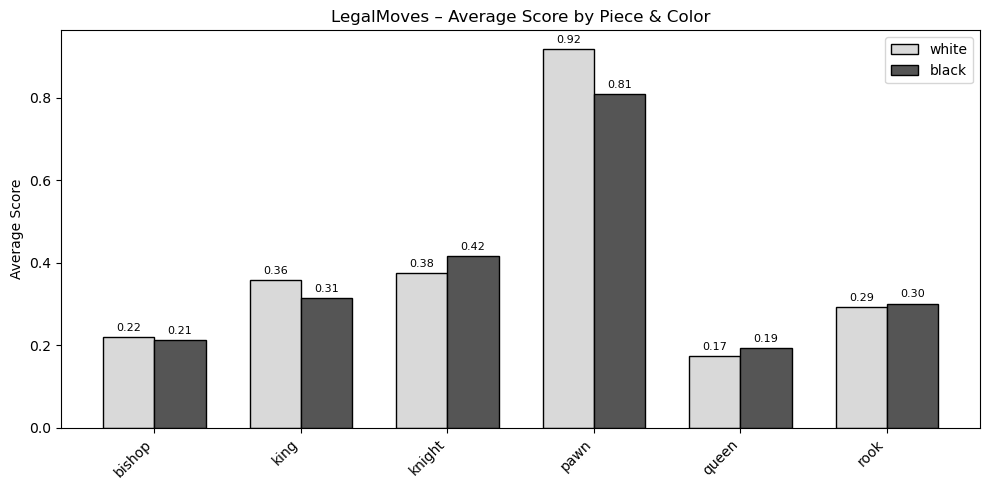

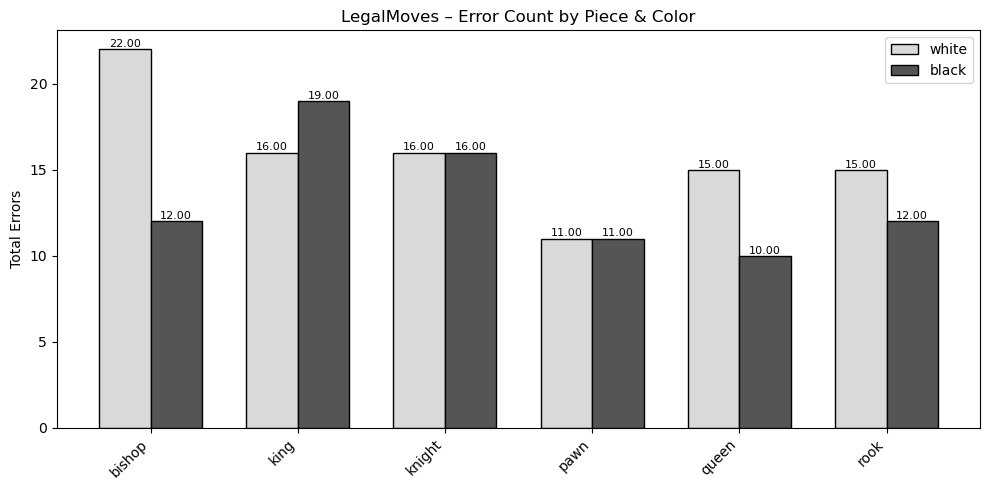

In [7]:
# 1) gather stats for legalmoves
stats = defaultdict(lambda: {"scores": [], "errors": 0})  # keyed by (piece, color)
for jf in (parent_dir / data_folder).glob("*legalmoves*.json"):
    for rec in json.load(open(jf, encoding="utf-8")).values():
        color, piece = rec["info"]["task_data"][0].split()   # e.g. "white pawn"
        key = (piece, color)

        raw = [s for s, _ in rec["score_answers"]]
        err_cnt = sum(1 for v in raw if not isinstance(v, (int, float)))

        nums = ([v if INCLUDE_ERRORS or isinstance(v, (int, float)) else 0
                 for v in raw]
                if INCLUDE_ERRORS else
                 [v for v in raw if isinstance(v, (int, float))])
        if not nums:
            continue

        stats[key]["scores"].append(sum(nums) / len(nums))
        stats[key]["errors"] += err_cnt

# 2) align into piece‑centric arrays (white / black)
pieces = sorted({p for p, _ in stats})
avg_white, avg_black, err_white, err_black = [], [], [], []

for p in pieces:
    avg_white.append(np.mean(stats[(p, "white")]["scores"]) if (p, "white") in stats else 0)
    avg_black.append(np.mean(stats[(p, "black")]["scores"]) if (p, "black") in stats else 0)
    err_white.append(stats[(p, "white")]["errors"] if (p, "white") in stats else 0)
    err_black.append(stats[(p, "black")]["errors"] if (p, "black") in stats else 0)

# 3) helper for twin‑bar plot
def twin_bar(values_w, values_b, title, ylabel):
    x = np.arange(len(pieces))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width/2, values_w, width, label="white", color=light_col, edgecolor="black")
    ax.bar(x + width/2, values_b, width, label="black", color=dark_col,  edgecolor="black")

    ax.set_xticks(x)
    ax.set_xticklabels(pieces, rotation=45, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

    for i, v in enumerate(values_w):
        ax.text(i - width/2, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
    for i, v in enumerate(values_b):
        ax.text(i + width/2, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

# 4) plot Average Score and Error Count
twin_bar(avg_white, avg_black, "LegalMoves – Average Score by Piece & Color", "Average Score")
twin_bar(err_white, err_black, "LegalMoves – Error Count by Piece & Color", "Total Errors")